In [ ]:
pip install tensorflow matplotlib scipy pillow

In [ ]:
pip install tensorflow-gan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.1/367.1 kB 19.4 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

# Reproducibility
tf.random.set_seed(42)

# Hyperparameters
LATENT_DIM = 100
BATCH_SIZE = 64
EPOCHS = 150

In [ ]:
(x_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize to [-1, 1]
x_train = (x_train.astype('float32') - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(60000).batch(BATCH_SIZE)

In [ ]:
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(LATENT_DIM,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(784, activation='tanh'),
        layers.Reshape((28, 28, 1))
    ])
    return model

In [ ]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(512),
        layers.LeakyReLU(0.2),
        layers.Dense(256),
        layers.LeakyReLU(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [ ]:
generator = build_generator()
discriminator = build_discriminator()

cross_entropy = tf.keras.losses.BinaryCrossentropy()

def d_loss(real, fake):
    real_loss = cross_entropy(tf.ones_like(real), real)
    fake_loss = cross_entropy(tf.zeros_like(fake), fake)
    return real_loss + fake_loss

def g_loss(fake):
    return cross_entropy(tf.ones_like(fake), fake)

g_optimizer = tf.keras.optimizers.Adam(0.0002)
d_optimizer = tf.keras.optimizers.Adam(0.0002)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
@tf.function
def train_step(real_images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise)

        real_output = discriminator(real_images)
        fake_output = discriminator(fake_images)

        loss_g = g_loss(fake_output)
        loss_d = d_loss(real_output, fake_output)

    grads_g = gen_tape.gradient(loss_g, generator.trainable_variables)
    grads_d = disc_tape.gradient(loss_d, discriminator.trainable_variables)

    g_optimizer.apply_gradients(zip(grads_g, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(grads_d, discriminator.trainable_variables))

    return loss_g, loss_d

In [ ]:
for epoch in range(EPOCHS):
    for image_batch in dataset:
        loss_g, loss_d = train_step(image_batch)

    print(f"Epoch {epoch+1}: G={loss_g:.4f}, D={loss_d:.4f}")

Epoch 1: G=13.1608, D=0.0129
Epoch 2: G=2.9892, D=0.0873
Epoch 3: G=4.0816, D=0.0692
Epoch 4: G=6.4395, D=0.0072
Epoch 5: G=7.6896, D=0.0072
Epoch 6: G=4.5376, D=0.1878
Epoch 7: G=4.6600, D=0.0246
Epoch 8: G=5.3398, D=0.1094
Epoch 9: G=6.2893, D=0.0151
Epoch 10: G=6.6167, D=0.3476
Epoch 11: G=3.8749, D=0.1493
Epoch 12: G=4.1927, D=0.1057
Epoch 13: G=4.2307, D=0.2139
Epoch 14: G=5.4024, D=0.1927
Epoch 15: G=3.1939, D=0.1481
Epoch 16: G=3.5102, D=0.1245
Epoch 17: G=2.5944, D=0.4858
Epoch 18: G=4.8467, D=0.3007
Epoch 19: G=4.3143, D=0.7004
Epoch 20: G=2.8113, D=0.4040
Epoch 21: G=2.4067, D=0.5416
Epoch 22: G=3.7834, D=0.2405
Epoch 23: G=2.9912, D=0.3578
Epoch 24: G=3.8689, D=0.3752
Epoch 25: G=2.7587, D=0.4563
Epoch 26: G=3.1523, D=0.8233
Epoch 27: G=2.3974, D=0.5666
Epoch 28: G=2.2409, D=0.3872
Epoch 29: G=3.5853, D=0.7172
Epoch 30: G=1.9420, D=0.3490
Epoch 31: G=2.9589, D=0.6277
Epoch 32: G=2.2163, D=0.5768
Epoch 33: G=2.4361, D=0.3904
Epoch 34: G=3.0737, D=0.5780
Epoch 35: G=2.0936, D=

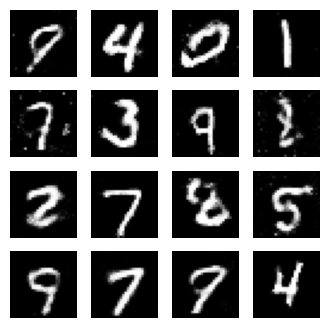

In [ ]:
def generate_images(model, n=16):
    noise = tf.random.normal([n, LATENT_DIM])
    images = model(noise, training=False)

    plt.figure(figsize=(4,4))
    for i in range(n):
        plt.subplot(4,4,i+1)
        plt.imshow(images[i,:,:,0]*127.5+127.5, cmap='gray')
        plt.axis('off')
    plt.show()

generate_images(generator)

In [ ]:
from PIL import Image

os.makedirs("fake_images", exist_ok=True)
os.makedirs("real_images", exist_ok=True)

# Save fake images
for i in range(1000):
    noise = tf.random.normal([1, LATENT_DIM])
    img = generator(noise)[0]
    img = ((img + 1) * 127.5).numpy().astype(np.uint8).squeeze()
    Image.fromarray(img).save(f"fake_images/{i}.png")

# Save real images
for i in range(1000):
    img = ((x_train[i] + 1) * 127.5).astype(np.uint8).squeeze()
    Image.fromarray(img).save(f"real_images/{i}.png")

10

In [ ]:
from scipy.linalg import sqrtm
import tensorflow as tf
import numpy as np

# Load InceptionV3
inception = tf.keras.applications.InceptionV3(
    include_top=False,
    pooling='avg',
    input_shape=(299, 299, 3)
)

def preprocess(images):
    images = tf.image.resize(images, (299, 299))
    images = tf.image.grayscale_to_rgb(images)
    return tf.keras.applications.inception_v3.preprocess_input(images)

def get_features(images, batch_size=100):
    features = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        batch = preprocess(batch)
        pred = inception(batch, training=False)
        features.append(pred.numpy())
    return np.vstack(features)

def calculate_fid(real_images, fake_images):
    act1 = get_features(real_images)
    act2 = get_features(fake_images)

    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)

    ssdiff = np.sum((mu1 - mu2)**2)

    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = ssdiff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

In [ ]:
real_images = x_train[:1000]

noise = tf.random.normal([1000, LATENT_DIM])
fake_images = generator(noise)

fid_score = calculate_fid(real_images, fake_images)

print("FID Score:", fid_score)

FID Score: 1.0920100773933925


/tmp/ipykernel_11035/3386209047.py:35: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1 @ sigma2)


In [ ]:
classifier = tf.keras.Sequential([
    layers.Flatten(input_shape=(28,28,1)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

classifier.fit(x_train, y_train, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8868 - loss: 0.3826
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9415 - loss: 0.1982
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9563 - loss: 0.1473
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9650 - loss: 0.1183
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9706 - loss: 0.1005


In [ ]:
def classifier_confidence(generator, classifier, samples=1000):
    noise = tf.random.normal([samples, LATENT_DIM])
    images = generator(noise)

    preds = classifier(images)
    confidence = tf.reduce_max(preds, axis=1)

    return tf.reduce_mean(confidence)

print("Classifier Confidence:", classifier_confidence(generator, classifier).numpy())

Classifier Confidence: 0.92438304


In [ ]:
def inception_score(generator, classifier, n_samples=1000):
    noise = tf.random.normal([n_samples, LATENT_DIM])
    images = generator(noise)

    preds = classifier(images).numpy()
    py = np.mean(preds, axis=0)

    kl = preds * (np.log(preds + 1e-10) - np.log(py + 1e-10))
    score = np.exp(np.mean(np.sum(kl, axis=1)))

    return score

print("Inception Score:", inception_score(generator, classifier))

Inception Score: 6.643551


In [ ]:
!pip install tensorflow-gan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.1/367.1 kB 11.9 MB/s eta 0:00:00
